Loading asset projects/gee-personal-483416/assets/RFTrainingAsset...
Starting learning curve generation. This may take a few minutes...
Testing 10 samples per class (40 total rows)...
   Accuracy: 0.9525
Testing 50 samples per class (200 total rows)...
   Accuracy: 0.9675
Testing 100 samples per class (400 total rows)...
   Accuracy: 0.9694
Testing 500 samples per class (2000 total rows)...
   Accuracy: 0.9811
Testing 1000 samples per class (4000 total rows)...
   Accuracy: 0.9893
Testing 2500 samples per class (10000 total rows)...
   Accuracy: 0.9924
Testing 5000 samples per class (20000 total rows)...
   Accuracy: 0.9951
Testing 10000 samples per class (40000 total rows)...
   Accuracy: 0.9956
Testing 15000 samples per class (60000 total rows)...
   Accuracy: 0.9963
Testing 20000 samples per class (80000 total rows)...
   Accuracy: 0.9961
Testing 25000 samples per class (100000 total rows)...
   Accuracy: 0.9966
Testing 30000 samples per class (120000 total rows)...
   Accuracy: 0.9

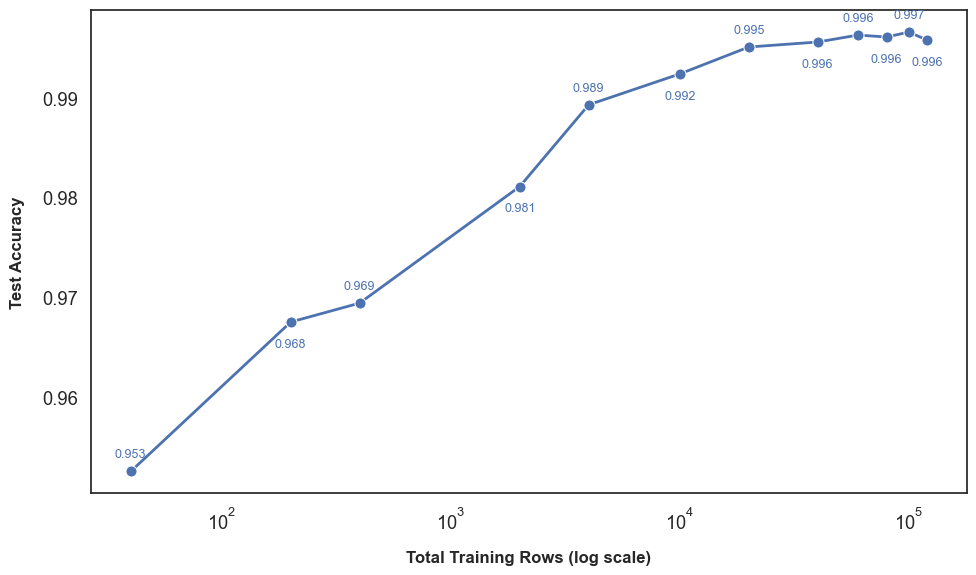

In [2]:
import ee
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Earth Engine
project_id = 'gee-personal-483416'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 1. Constants and Hyperparameters
RANDOM_SEED = 12
ASSET_ID = "projects/gee-personal-483416/assets/RFTrainingAsset"
features = ["red", "green", "blue", "nir", "swir1", "swir2", "sensor"]
target = "class_id"
specific_class_ids = [1, 2, 3, 4]

best_params = {
    'numberOfTrees': 198, 
    'variablesPerSplit': 3, 
    'minLeafPopulation': 5, 
    'bagFraction': 0.9428329774159232, 
    'seed': RANDOM_SEED
}

# 2. Load and Split Data
print(f"Loading asset {ASSET_ID}...")
raw_data = ee.FeatureCollection(ASSET_ID)

data_with_folds = raw_data.randomColumn(columnName='fold_rand', seed=RANDOM_SEED)

# Train pool (80%) and Test pool (20%)
train_pool = data_with_folds.filter(ee.Filter.lt('fold_rand', 0.8))
test_pool = data_with_folds.filter(ee.Filter.gte('fold_rand', 0.8))

# Lock in a static, manageable test set for evaluation (e.g., 2500 per class = 10,000 total)
# This prevents GEE timeouts during the loop
fixed_test_subsets = []
for class_id in specific_class_ids:
    class_test = test_pool.filter(ee.Filter.eq(target, class_id))\
        .randomColumn('test_rand', seed=RANDOM_SEED)\
        .sort('test_rand')\
        .limit(2500)
    fixed_test_subsets.append(class_test)

fixed_test_set = fixed_test_subsets[0]
for i in range(1, len(fixed_test_subsets)):
    fixed_test_set = fixed_test_set.merge(fixed_test_subsets[i])

# 3. Define the Sample Sizes to Test (Number of samples PER CLASS)
# This will test total dataset sizes of: 400, 2000, 4000, 10000, 20000, 40000, 80000
sample_sizes = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 25000, 30000]
accuracies = []

print("Starting learning curve generation. This may take a few minutes...")

# 4. Loop Through Sizes, Train, and Evaluate
for size in sample_sizes:
    print(f"Testing {size} samples per class ({size * 4} total rows)...")
    
    # Create the stratified training subset for this size
    stratified_train_subsets = []
    for class_id in specific_class_ids:
        class_train = train_pool.filter(ee.Filter.eq(target, class_id))\
            .randomColumn('train_rand', seed=RANDOM_SEED)\
            .sort('train_rand')\
            .limit(size)
        stratified_train_subsets.append(class_train)
        
    current_train_set = stratified_train_subsets[0]
    for i in range(1, len(stratified_train_subsets)):
        current_train_set = current_train_set.merge(stratified_train_subsets[i])
        
    # Train the classifier
    classifier = ee.Classifier.smileRandomForest(**best_params)\
        .train(
            features=current_train_set,
            classProperty=target,
            inputProperties=features
        )
        
    # Classify the fixed test set
    validated = fixed_test_set.classify(classifier)
    
    # Calculate accuracy and pull to local machine
    accuracy = validated.errorMatrix(target, 'classification').accuracy().getInfo()
    accuracies.append(accuracy)
    
    print(f"   Accuracy: {accuracy:.4f}")

# 5. Plot the Results
total_rows = [size * 4 for size in sample_sizes]

sns.set_context('paper')
sns.set_theme(style="white", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    x=total_rows,
    y=accuracies,
    marker='o',
    linewidth=2,
    markersize=8,
    color='b',
    ax=ax
)

for i, (x, y) in enumerate(zip(total_rows, accuracies)):
    offset = 10 if i % 2 == 0 else -18
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", 
                xytext=(0, offset), ha='center', fontsize=9, color='b')

ax.set_xscale('log')
ax.set_xlabel('Total Training Rows (log scale)', fontsize=12, weight='bold', labelpad=12)
ax.set_ylabel('Test Accuracy', fontsize=12, weight='bold', labelpad=12)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

Loading asset projects/gee-personal-483416/assets/RFTrainingAsset...
Starting learning curve generation. This may take a few minutes...
Testing 10 samples per class (40 total rows)...
   Accuracy: 0.9525
Testing 50 samples per class (200 total rows)...
   Accuracy: 0.9675
Testing 100 samples per class (400 total rows)...
   Accuracy: 0.9694
Testing 500 samples per class (2000 total rows)...
   Accuracy: 0.9811
Testing 1000 samples per class (4000 total rows)...
   Accuracy: 0.9893
Testing 2500 samples per class (10000 total rows)...
   Accuracy: 0.9924
Testing 5000 samples per class (20000 total rows)...
   Accuracy: 0.9951
Testing 10000 samples per class (40000 total rows)...
   Accuracy: 0.9956
Testing 15000 samples per class (60000 total rows)...
   Accuracy: 0.9963
Testing 20000 samples per class (80000 total rows)...
   Accuracy: 0.9961
Testing 25000 samples per class (100000 total rows)...
   Accuracy: 0.9966
Testing 30000 samples per class (120000 total rows)...
   Accuracy: 0.9

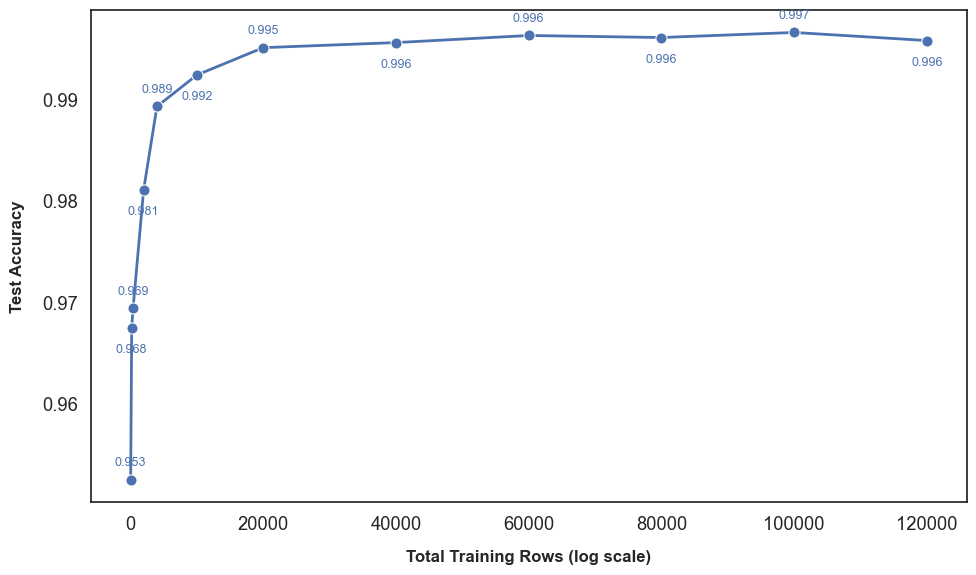

In [3]:
import ee
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Earth Engine
project_id = 'gee-personal-483416'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 1. Constants and Hyperparameters
RANDOM_SEED = 12
ASSET_ID = "projects/gee-personal-483416/assets/RFTrainingAsset"
features = ["red", "green", "blue", "nir", "swir1", "swir2", "sensor"]
target = "class_id"
specific_class_ids = [1, 2, 3, 4]

best_params = {
    'numberOfTrees': 198, 
    'variablesPerSplit': 3, 
    'minLeafPopulation': 5, 
    'bagFraction': 0.9428329774159232, 
    'seed': RANDOM_SEED
}

# 2. Load and Split Data
print(f"Loading asset {ASSET_ID}...")
raw_data = ee.FeatureCollection(ASSET_ID)

data_with_folds = raw_data.randomColumn(columnName='fold_rand', seed=RANDOM_SEED)

# Train pool (80%) and Test pool (20%)
train_pool = data_with_folds.filter(ee.Filter.lt('fold_rand', 0.8))
test_pool = data_with_folds.filter(ee.Filter.gte('fold_rand', 0.8))

# Lock in a static, manageable test set for evaluation (e.g., 2500 per class = 10,000 total)
# This prevents GEE timeouts during the loop
fixed_test_subsets = []
for class_id in specific_class_ids:
    class_test = test_pool.filter(ee.Filter.eq(target, class_id))\
        .randomColumn('test_rand', seed=RANDOM_SEED)\
        .sort('test_rand')\
        .limit(2500)
    fixed_test_subsets.append(class_test)

fixed_test_set = fixed_test_subsets[0]
for i in range(1, len(fixed_test_subsets)):
    fixed_test_set = fixed_test_set.merge(fixed_test_subsets[i])

# 3. Define the Sample Sizes to Test (Number of samples PER CLASS)
# This will test total dataset sizes of: 400, 2000, 4000, 10000, 20000, 40000, 80000
sample_sizes = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 25000, 30000]
accuracies = []

print("Starting learning curve generation. This may take a few minutes...")

# 4. Loop Through Sizes, Train, and Evaluate
for size in sample_sizes:
    print(f"Testing {size} samples per class ({size * 4} total rows)...")
    
    # Create the stratified training subset for this size
    stratified_train_subsets = []
    for class_id in specific_class_ids:
        class_train = train_pool.filter(ee.Filter.eq(target, class_id))\
            .randomColumn('train_rand', seed=RANDOM_SEED)\
            .sort('train_rand')\
            .limit(size)
        stratified_train_subsets.append(class_train)
        
    current_train_set = stratified_train_subsets[0]
    for i in range(1, len(stratified_train_subsets)):
        current_train_set = current_train_set.merge(stratified_train_subsets[i])
        
    # Train the classifier
    classifier = ee.Classifier.smileRandomForest(**best_params)\
        .train(
            features=current_train_set,
            classProperty=target,
            inputProperties=features
        )
        
    # Classify the fixed test set
    validated = fixed_test_set.classify(classifier)
    
    # Calculate accuracy and pull to local machine
    accuracy = validated.errorMatrix(target, 'classification').accuracy().getInfo()
    accuracies.append(accuracy)
    
    print(f"   Accuracy: {accuracy:.4f}")

# 5. Plot the Results
total_rows = [size * 4 for size in sample_sizes]

sns.set_context('paper')
sns.set_theme(style="white", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    x=total_rows,
    y=accuracies,
    marker='o',
    linewidth=2,
    markersize=8,
    color='b',
    ax=ax
)

for i, (x, y) in enumerate(zip(total_rows, accuracies)):
    offset = 10 if i % 2 == 0 else -18
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", 
                xytext=(0, offset), ha='center', fontsize=9, color='b')

ax.set_xlabel('Total Training Rows (log scale)', fontsize=12, weight='bold', labelpad=12)
ax.set_ylabel('Test Accuracy', fontsize=12, weight='bold', labelpad=12)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/learning_curve_nonlog.png', dpi=300, bbox_inches='tight')
plt.show()